# **Intento 3: Examen de Calificación**

**Data Science Salaries 2023**
El conjunto de datos de salarios de trabajo de ciencia de datos contiene 11 columnas, cada una de las cuales es:

* work_year: El año en que se pagó el salario.
* experience_level: El nivel de experiencia en el trabajo durante el año
* employment_type: El tipo de empleo para el puesto
* job_title: El puesto trabajado durante el año.
* salario: El monto total del salario bruto pagado.
* salary_currency: La moneda del salario pagado como un código de moneda ISO 4217.
* salaryinusd: El salario en USD
* employee_residence: País de residencia principal del empleado durante el año * laboral según el código de país ISO 3166.
* remote_ratio: La cantidad total de trabajo realizado de forma remota
* company_location: El país de la oficina principal del empleador o de la sucursal contratante
* company_size: El número medio de personas que trabajaron para la empresa durante el año

# **Limpieza de datos con Python:**
* Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.
* Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
* Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘Junior’, ‘junior’, ‘JUNIOR’).
* Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.
* Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, un salario anual de 1 millón de dólares para un puesto de entrada).

# Preparo Entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# Importo  DataFrame examen
path = "/content/drive/MyDrive/Bootcamp-CSDATOS/examen3/ds_salaries.csv"
df = pd.read_csv(path)
# preparo un dataframe secundario para preservar el df original
df2 = df.copy()

# **Análisis de dataframe**

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [ ]:
df2.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
df2.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


In [ ]:
#Normalizamos nombres de columnas, sin espacios antes o posteriores al nombre, reemplazo espacios por _ y todo escrito en minúsculas
df2.columns = df2.columns.str.lower().str.strip().str.replace(" ", "_")

In [ ]:
df2.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
df2.shape

(3755, 11)

In [ ]:
df2.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
work_year,3755.0,2022.37,0.69,2020.0,2022.0,2022.0,2023.0,2023.0
salary,3755.0,190695.57,671676.50,6000.0,100000.0,138000.0,180000.0,30400000.0
salary_in_usd,3755.0,137570.39,63055.63,5132.0,95000.0,135000.0,175000.0,450000.0
remote_ratio,3755.0,46.27,48.59,0.0,0.0,0.0,100.0,100.0


In [ ]:
# Identificar valores nulos en todo el DataFrame
print(df2.isnull().sum())

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [ ]:
# Verificar/Revisar duplicados. ---> Hay 1171 registros duplicados
df2.duplicated().sum()

np.int64(1171)

**Se verifica que hay 1171 registros duplicados, que corresponden a casi un 31% del dataset**

In [ ]:
# Revisar duplicados.
df2[df2.duplicated()] # muestra los registros duplcados en este ejemplo 2116 y 2128 ambos tenian un duplicado

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
115,2023,SE,FT,Data Scientist,150000,USD,150000,US,0,US,M
123,2023,SE,FT,Analytics Engineer,289800,USD,289800,US,0,US,M
153,2023,MI,FT,Data Engineer,100000,USD,100000,US,100,US,M
154,2023,MI,FT,Data Engineer,70000,USD,70000,US,100,US,M
160,2023,SE,FT,Data Engineer,115000,USD,115000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
3439,2022,MI,FT,Data Scientist,78000,USD,78000,US,100,US,M
3440,2022,SE,FT,Data Engineer,135000,USD,135000,US,100,US,M
3441,2022,SE,FT,Data Engineer,115000,USD,115000,US,100,US,M
3586,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L


In [ ]:
# Valido el shape.
print(df.shape)

(3755, 11)


In [ ]:
# Elimino, usando inplace = True para que quede modificado el dataframe
df2.drop_duplicates(inplace=True) #elimina , se reinicia el index


In [ ]:
# Valido el nuevo shape.
print(df2.shape)

(2584, 11)


In [ ]:
#Valido que no hay duplicados
# Verificar/Revisar duplicados. ---> No hay duplicados
df2.duplicated().sum()

np.int64(0)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


In [ ]:
#Nuevos datos estadísticos generales
df2.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
work_year,2584.0,2022.30,0.75,2020.0,2022.0,2022.0,2023.0,2023.0
salary,2584.0,210365.30,808037.54,6000.0,90000.0,134630.0,182562.5,30400000.0
salary_in_usd,2584.0,133409.28,67136.84,5132.0,84975.0,130000.0,175000.0,450000.0
remote_ratio,2584.0,50.48,48.16,0.0,0.0,50.0,100.0,100.0


Obs: El 'salary' max es de 30400000.0 revisé ordenando desde el salary_in_usd, por que es comparable con todos

In [ ]:
fil_empleo= df2['job_title'] == 'Data Scientist'
df_sorted = df2[fil_empleo].sort_values(by=["salary"], ascending=False)
df_sorted

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3669,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
3646,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
2358,2022,EN,FT,Data Scientist,6600000,HUF,17684,HU,100,HU,M
3061,2022,MI,FT,Data Scientist,4200000,INR,53416,IN,100,ID,L
1738,2021,SE,FT,Data Scientist,4000000,INR,54094,IN,100,IN,L
...,...,...,...,...,...,...,...,...,...,...,...
3124,2022,MI,FT,Data Scientist,25000,USD,25000,TR,50,TR,M
3638,2021,MI,FT,Data Scientist,21600,EUR,25532,RS,100,DE,S
3710,2020,EN,PT,Data Scientist,19000,EUR,21669,IT,50,IT,S
3527,2021,EN,FT,Data Scientist,13400,USD,13400,UA,100,UA,L


# **Supuesto 1: **
Revisados el sueldo de los Data Scientist en el año 2021, donde la pandemia requeria de profesionales del área para analizar acerca de contagiados, muertes, estadísticas de avance de la pandemia, etc... el sueldo del Data Scientist debió tener un incremento en el valor, y en este caso siendo UNICO en Chile corrobora aún mas que es justo su sueldo.

In [ ]:
# Agrupación entre nivel de experiencia, tipo de empleo y tranajo, para visualizar el promedio del salario que se reciben
fil_location=df2['company_location'] == 'CL'
df2[fil_location].groupby(['experience_level',"employment_type", 'job_title','company_location'])['salary_in_usd'].agg(['mean','max', 'min']).round(2)

,,,,mean,max,min
experience_level,employment_type,job_title,company_location,,,
MI,FT,Data Scientist,CL,40038.0,40038,40038


# **Supuesto 2: **
El sueldo que aparece mayor en la columna 'salary' es único, no hay otro trabajador que reciba sueldo en CLP, y al no poder comparar con otros decido dejarlo así, sin cambios, pues lo consideraré de acuerdo al mercado.



# **Continuación análisis**

In [ ]:
df2['experience_level'].value_counts()

,count
experience_level,
SE,1554
MI,664
EN,270
EX,96


In [ ]:
df2['employment_type'].value_counts()

,count
employment_type,
FT,2547
PT,17
CT,10
FL,10


In [ ]:
df2['salary'].describe().T.round(2)

,salary
count,2584.00
mean,210365.30
std,808037.54
min,6000.00
25%,90000.00
50%,134630.00
75%,182562.50
max,30400000.00


In [ ]:
df2['job_title'].value_counts().sort_values()

,count
job_title,
Data Management Specialist,1
Azure Data Engineer,1
Marketing Data Engineer,1
Principal Machine Learning Engineer,1
Manager Data Management,1
...,...
Analytics Engineer,91
Machine Learning Engineer,206
Data Analyst,396


In [ ]:
df2['salary_currency'].value_counts()

,count
salary_currency,
USD,2107
EUR,200
GBP,144
INR,59
CAD,25
AUD,9
BRL,6
SGD,6
PLN,5


In [ ]:
df2['employee_residence'].value_counts()

,count
employee_residence,
US,1893
GB,150
CA,81
IN,70
DE,47
...,...
RS,1
NZ,1
MD,1


In [ ]:
df2['company_location'].value_counts()

,count
company_location,
US,1929
GB,155
CA,83
IN,57
DE,55
...,...
CN,1
NZ,1
CL,1


In [ ]:
df2['company_size'].value_counts()

,count
company_size,
M,2028
L,409
S,147


In [ ]:
#Aplico por si algun nombre de la columna job_title tuviera espacios
df2['job_title'] = df2['job_title'].str.strip()

In [ ]:
df2['job_title'].value_counts()

,count
job_title,
Data Engineer,598
Data Scientist,538
Data Analyst,396
Machine Learning Engineer,206
Analytics Engineer,91
...,...
Principal Data Architect,1
Head of Machine Learning,1
Cloud Data Architect,1


In [ ]:
# Agrupación entre nivel de experiencia, tipo de empleo y trabajo, para visualizar el promedio del salario que se reciben

df2.groupby(['experience_level',"employment_type", 'job_title'])['salary_in_usd'].agg(['mean','max', 'min']).round(2)


mean  \
experience_level employment_type job_title                                        
EN               CT              Applied Machine Learning Scientist    30469.00   
                                 Business Data Analyst                100000.00   
                 FL              Data Analytics Consultant             50000.00   
                                 Machine Learning Engineer            100000.00   
                 FT              3D Computer Vision Researcher         35000.00   
...                                                                         ...   
SE               FT              Principal Data Scientist             169728.17   
                                 Principal Machine Learning Engineer  190000.00   
                                 Product Data Scientist                 8000.00   
                                 Research Engineer                    174773.18   
                                 Research Scientist                   171229.59   

                                                                         max  \
experience_level employment_type job_title                                     
EN               CT              Applied Machine Learning Scientist    30469   
                                 Business Data Analyst                100000   
                 FL              Data Analytics Consultant             50000   
                                 Machine Learning Engineer            100000   
                 FT              3D Computer Vision Researcher         50000   
...                                                                      ...   
SE               FT              Principal Data Scientist             235000   
                                 Principal Machine Learning Engineer  190000   
                                 Product Data Scientist                 8000   
                                 Research Engineer                    293000   
                                 Research Scientist                   370000   

                                                                         min  
experience_level employment_type job_title                                    
EN               CT              Applied Machine Learning Scientist    30469  
                                 Business Data Analyst                100000  
                 FL              Data Analytics Consultant             50000  
                                 Machine Learning Engineer            100000  
                 FT              3D Computer Vision Researcher         20000  
...                                                                      ...  
SE               FT              Principal Data Scientist              85847  
                                 Principal Machine Learning Engineer  190000  
                                 Product Data Scientist                 8000  
                                 Research Engineer                     85847  
                                 Research Scientist                    50000  

[212 rows x 3 columns]

In [ ]:
# Agrupación entre nivel de experiencia y tamaño de la enmpresa, para visualizar que tipo de empresa contrara mas a principiantes o senior?
df2.groupby(['experience_level',"company_size"]).size()

experience_level  company_size
EN                L                 96
                  M                125
                  S                 49
EX                L                 13
                  M                 77
                  S                  6
MI                L                132
                  M                483
                  S                 49
SE                L                168
                  M               1343
                  S                 43
dtype: int64

In [ ]:
df2.groupby(['experience_level',"company_size"])[['salary','salary_in_usd']].mean().round()

salary  salary_in_usd
experience_level company_size                         
EN               L             189716.0        71685.0
                 M             200861.0        78692.0
                 S             213565.0        59121.0
EX               L             623846.0       165363.0
                 M             194050.0       194972.0
                 S             200833.0       196827.0
MI               L             746759.0        88284.0
                 M             127423.0       109969.0
                 S             478193.0        58082.0
SE               L             392478.0       152469.0
                 M             156042.0       155582.0
                 S             150988.0       106875.0

In [ ]:
# Agrupación entre nivel de experiencia y tipo de empleo, para visualizar cuantos desempeñan trabajo remoto

df2.groupby(['experience_level',"employment_type", 'remote_ratio']).size().unstack(level='remote_ratio')

remote_ratio                        0     50     100
experience_level employment_type                    
EN               CT                 NaN   NaN    2.0
                 FL                 NaN   NaN    2.0
                 FT                77.0  58.0  117.0
                 PT                 NaN   6.0    8.0
EX               CT                 NaN   NaN    1.0
                 FT                48.0   6.0   41.0
MI               CT                 NaN   1.0    4.0
                 FL                 1.0   2.0    2.0
                 FT               294.0  68.0  289.0
                 PT                 NaN   2.0    1.0
SE               CT                 NaN   NaN    2.0
                 FL                 NaN   2.0    1.0
                 FT               766.0  42.0  741.0

In [ ]:
df2.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

# **Exploración de datos con Python**

**Visualizaciones exploratorias univariadas:**
* Crea dos tipos diferentes de visualizaciones univariadas.
*Cada visualización debe incluir una breve interpretación dentro del archivo de código.

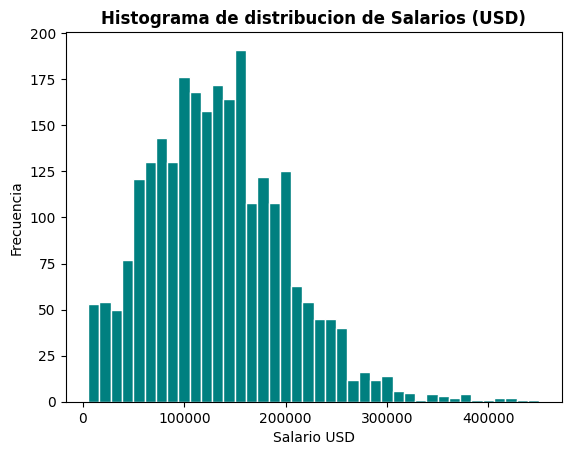

In [ ]:
#Visualización Univariada N° 1
plt.hist(df2["salary_in_usd"], bins=40, edgecolor="white", color="teal")
plt.title("Histograma de distribucion de Salarios (USD)", fontsize=12, fontweight="bold")
plt.xlabel("Salario USD")
plt.ylabel("Frecuencia")
plt.show()

**El histograma permite visualizar que los sueldos expresados en USD,  muestra una distribución sesgada a la derecha. La mayoría de los sueldos están entre 70,000 y 180,000 USD y sólo unos pocos superan 400000.

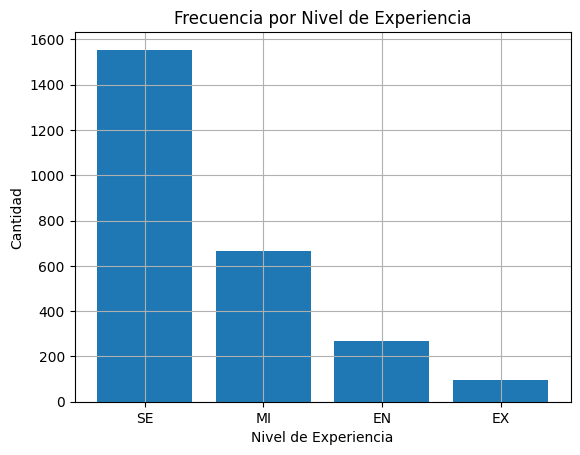

In [ ]:
# Visualización Univariada N° 2
# Calculo de la frecuencia de casa "experience_level"
experiencia = df2["experience_level"].value_counts()
# Crear gráfico.
plt.bar(experiencia.index, experiencia.values)

# Añadir título y etiquetas.
plt.title("Frecuencia por Nivel de Experiencia")
plt.xlabel("Nivel de Experiencia")
plt.ylabel("Cantidad")
plt.grid()
# Mostrar.
plt.show()

El gráfico de barra permite ver que los trabajadores con nivel Senior (SE) predominan en la data, y al contrario los trabadores Executive (Ex) son menos. Lo cual es lógico, pues los profesionales expertos siempre son mas demandados pq son una recurso humano escaso.



# **Visualizaciones exploratorias multivariadas: **
* Crea dos tipos diferentes de visualizaciones multivariadas.
* Cada visualización debe incluir una breve interpretación dentro del archivo de código.

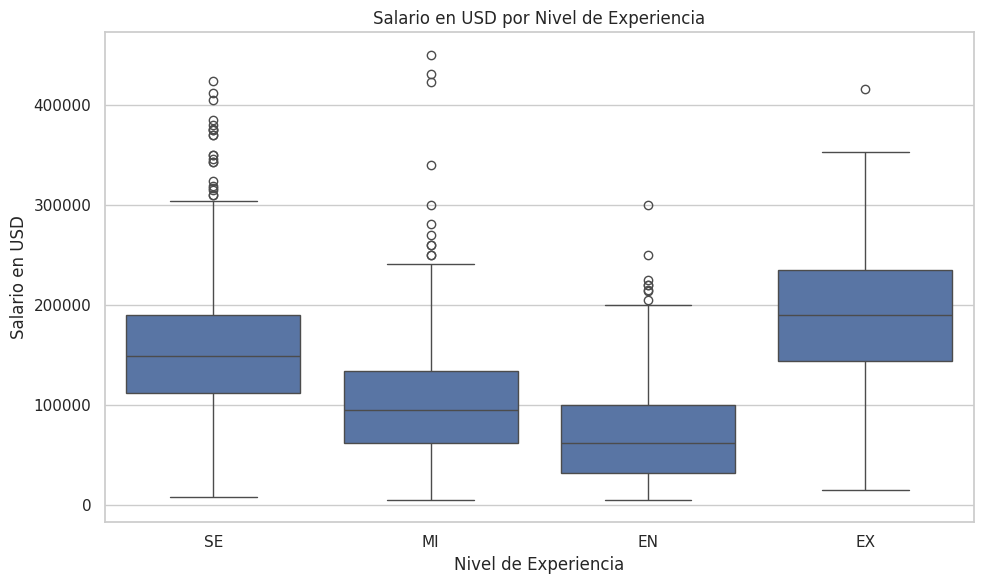

In [ ]:
# Visualización Multivariada N° 1

# Boxplot: salary_in_usd por experience_level
import seaborn as sns


# Configuración de estilo
sns.set(style="whitegrid")

# === Boxplot: salario por nivel de experiencia ===
plt.figure(figsize=(10, 6))
sns.boxplot(x="experience_level", y="salary_in_usd", data=df2)

# Títulos y etiquetas
plt.title("Salario en USD por Nivel de Experiencia")
plt.xlabel("Nivel de Experiencia")
plt.ylabel("Salario en USD")

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Los empleados tipo Executive (EX) y Senior (SE) presentan los salarios más altos.

Hay mayor dispersión salarial en esos niveles, lo que indica diferencias sustanciales dentro del mismo nivel.

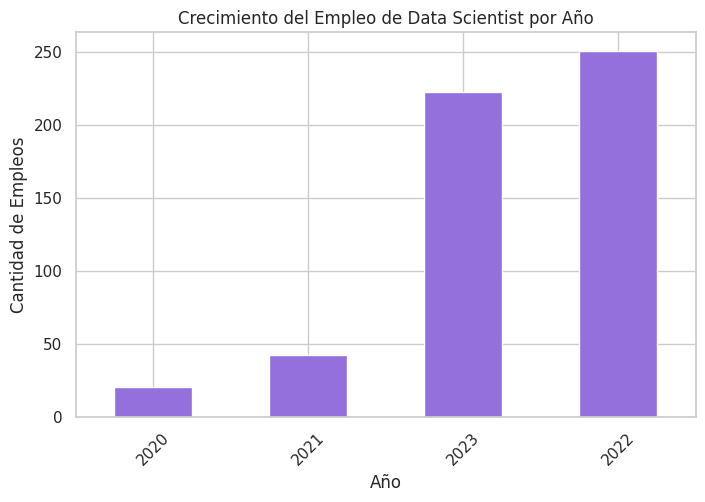

In [ ]:
# Visualización Multivariada N° 2


# Filtrar solo "Data Scientist"
df_dc = df2[df2["job_title"] == "Data Scientist"]

# Contar cuántos hay por año
dc_num = df_dc["work_year"].value_counts().sort_values()

# Graficar evolución
plt.figure(figsize=(8, 5))
dc_num.plot(kind="bar", color="mediumpurple")

# Títulos y etiquetas
plt.title("Crecimiento del Empleo de Data Scientist por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad de Empleos")
plt.xticks(rotation=45)

plt.grid
plt.show()

El gráfico permite visualizar cómo el  empleo de Data Scientist  registra un incremento desde el año 2020 al 2022. Se ve claramento cuánto ha crecido la
 la demanda, siendo un crecimiento sostenido.


# **Análisis adicional:**
* Estadísticas descriptivas: Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas.
* Identificación de tendencias: Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.

**Estadísticas descriptivas:** Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas

In [ ]:
df2.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
work_year,2584.0,2022.30,0.75,2020.0,2022.0,2022.0,2023.0,2023.0
salary,2584.0,210365.30,808037.54,6000.0,90000.0,134630.0,182562.5,30400000.0
salary_in_usd,2584.0,133409.28,67136.84,5132.0,84975.0,130000.0,175000.0,450000.0
remote_ratio,2584.0,50.48,48.16,0.0,0.0,50.0,100.0,100.0


In [ ]:
df2.groupby( ['work_year','job_title'])[["salary_in_usd",'salary','remote_ratio']].agg([ "mean", "median", "std", "min", "max"]).reset_index()

work_year                 job_title  salary_in_usd            \
                                                  mean    median   
0        2020              AI Scientist   45896.000000   45896.0   
1        2020           BI Data Analyst   98000.000000   98000.0   
2        2020         Big Data Engineer   97690.333333  109024.0   
3        2020     Business Data Analyst  110000.000000  100000.0   
4        2020  Computer Vision Engineer   60000.000000   60000.0   
..        ...                       ...            ...       ...   
195      2023  Principal Data Scientist   85847.000000   85847.0   
196      2023      Product Data Analyst   16414.000000   16414.0   
197      2023         Research Engineer  158416.428571  152500.0   
198      2023        Research Scientist  171624.921053  150900.0   
199      2023    Software Data Engineer   62510.000000   62510.0   

                                        salary                           \
              std    min     max          mean     median           std   
0             NaN  45896   45896  3.000000e+05   300000.0           NaN   
1             NaN  98000   98000  9.800000e+04    98000.0           NaN   
2    24111.689122  70000  114047  8.500000e+04    85000.0  15000.000000   
3    21794.494718  95000  135000  1.100000e+05   100000.0  21794.494718   
4             NaN  60000   60000  6.000000e+04    60000.0           NaN   
..            ...    ...     ...           ...        ...           ...   
195           NaN  85847   85847  8.000000e+04    80000.0           NaN   
196           NaN  16414   16414  1.350000e+06  1350000.0           NaN   
197  55725.384823  60000  293000  1.579466e+05   152500.0  56279.969006   
198  64642.431847  70000  370000  1.702329e+05   150900.0  65118.119409   
199  17691.811665  50000   75020  7.500000e+04    75000.0  35355.339059   

                      remote_ratio                              
         min      max         mean median        std  min  max  
0     300000   300000    50.000000   50.0        NaN   50   50  
1      98000    98000     0.000000    0.0        NaN    0    0  
2      70000   100000    83.333333  100.0  28.867513   50  100  
3      95000   135000    66.666667  100.0  57.735027    0  100  
4      60000    60000   100.000000  100.0        NaN  100  100  
..       ...      ...          ...    ...        ...  ...  ...  
195    80000    80000   100.000000  100.0        NaN  100  100  
196  1350000  1350000   100.000000  100.0        NaN  100  100  
197    60000   293000    21.428571    0.0  41.785545    0  100  
198    70000   370000    22.368421    0.0  41.422948    0  100  
199    50000   100000    75.000000   75.0  35.355339   50  100  

[200 rows x 17 columns]

**Identificación de tendencias:** Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.

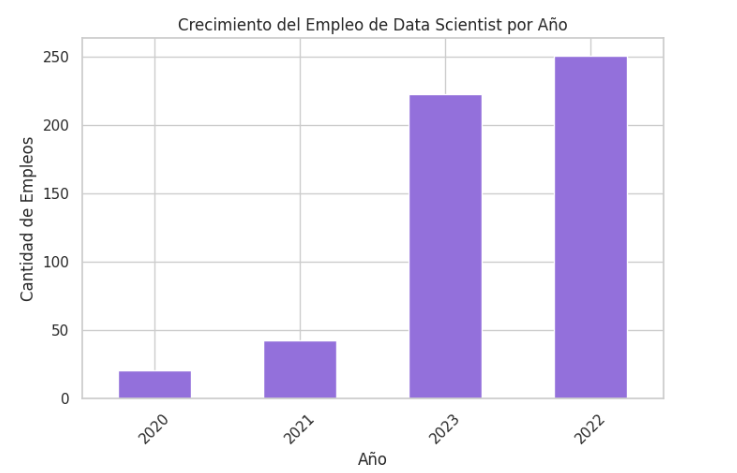

Del dataframe visto en este examen me parece muy clara, esperada y acorde a la realidad actual de los empleos TI y carreras relacionadas, es el crecimiento que a partir del año 2020 se evidencia en esta data. La actualidad post pandemia, determinó la necesidad de trabajar y analizar los datos, y esto se extrapola a todas las demás áreas, por ello, este segmento profesional seguirá en ascenso. Nos movemos a través de los datos, todas las decisiones se deben tomar de acuerdo a los datos, que se han almacenado por años, y ellos no pueden quedar simplemente como referencias, con ellos se debe trabajar para seguir avanzando en medicina, en educación, en agricultura, etc.

En el dataset, se ,muestra también como las empresas, de acuerdo a su tamaño, contratan a sus trabajadores,

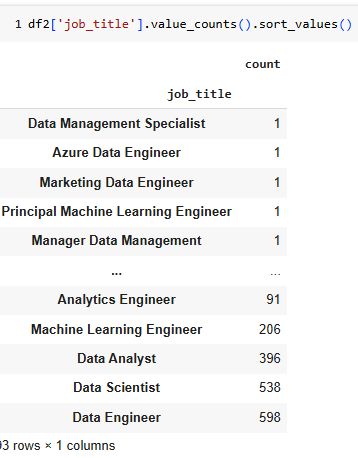

El anáñisis de los empleos, muestra también la tendecia actual, de mas profesionales como Machine Learning Engineer, Data Analyst, Data Scientist y Data Engineer, todos profesionales del área de la ciencia de datosm que hoy en día , si bien no son carreras nuevas, son carreras que requeriran mas profesionales preparados.

In [ ]:
import pandas as pd



# Contar la cantidad de trabajos por tipo de modalidad según remote_ratio
remote_counts = df2['remote_ratio'].value_counts().sort_index()

# Calcular el porcentaje
remote_percentages = (remote_counts / len(df)) * 100

# Combinar en un DataFrame
remote_stats = pd.DataFrame({
    'Cantidad': remote_counts,
    'Porcentaje (%)': remote_percentages.round(2)
})

# Renombrar los índices para mayor claridad
remote_stats.index = remote_stats.index.map({
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
})

print(remote_stats)

              Cantidad  Porcentaje (%)
remote_ratio                          
Presencial        1186           31.58
Híbrido            187            4.98
Remoto            1211           32.25


# **Análisis de trabajos remotos**

In [ ]:
tipos_remotos = df2.groupby(["remote_ratio",'company_size']).size().reset_index(name="Cantidad")
tipos_remotos

,remote_ratio,company_size,Cantidad
0,0,L,95
1,0,M,1067
2,0,S,24
3,50,L,108
4,50,M,47
5,50,S,32
6,100,L,206
7,100,M,914
8,100,S,91


# **Conclusión Final**

El análisis del dataset revela patrones claros y significativos en el mercado laboral de ciencia de datos entre los años 2020 y 2023. Se destacan las siguientes conclusiones principales:
1.	Crecimiento del Empleo en Ciencia de Datos:
* Se observa un aumento sostenido en la contratación de profesionales, especialmente en los niveles Senior (SE) y en el rol de Data Scientist, consolidando este cargo como uno de los más demandados del sector.
2.	Relación entre Experiencia y Salario:
* Los niveles de experiencia Senior (SE) y Executive (EX) están asociados a los salarios más altos, con una dispersión significativa, lo que refleja una alta variabilidad dentro de estos niveles.
3.	Tendencias en Modalidad de Trabajo:
* Las posiciones remotas (100%) son las más frecuentes, especialmente en empresas medianas (M), lo que refleja una tendencia establecida hacia la virtualización del trabajo en esta área.

En conjunto, los datos analizados muestran una evolución positiva y dinámica del campo de la ciencia de datos, tanto en términos de demanda de talento como en transformación del modelo laboral. Esta información es clave para orientar decisiones académicas, profesionales y estratégicas en el área tecnológica.


# Sugerencias de Target y Modelos de ML para `ds_salaries.csv`

| Target (Variable Objetivo) | Descripción de la Predicción                          | Modelo Recomendado        |
|----------------------------|--------------------------------------------------------|---------------------------|
| salary_in_usd              | Predecir el salario anual normalizado en USD          | Regresión Lineal, Random Forest Regressor |
| experience_level           | Clasificar el nivel de experiencia del trabajador     | Árbol de Decisión, SVM Classifier         |
| employment_type            | Predecir tipo de contrato (FT, PT, etc.)              | Regresión Logística, Random Forest Classifier |
| remote_ratio               | Estimar el porcentaje de trabajo remoto               | Regresión Lineal, KNN Regressor           |
| company_size               | Clasificar el tamaño de la empresa                    | Árbol de Decisión, KNN Classifier         |
